# Comprendre les unités des signaux acoustiques et des spectrogrammes avec SciPy

## Objectif

Ce notebook a pour objectif de comprendre les unités physiques des différentes représentations d'un signal acoustique, depuis le domaine temporel jusqu'au spectrogramme.

Le contexte est celui de l'acoustique sous-marine, où la grandeur mesurée est la pression acoustique exprimée en Pascal (Pa). Les niveaux sont référencés à 1 µPa. 

Dans la mesure du possible on essaiera ici de se référer aux standards données par [1]. 


## Références 

[1] Ainslie, M. A., Halvorsen, M. B., & Robinson, S. P. (2022). A Terminology Standard for Underwater Acoustics and the Benefits of International Standardization. IEEE Journal of Oceanic Engineering, 47(1), 179–200. https://doi.org/10.1109/JOE.2021.3085947

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from publication.publication_figure import PubFigure, color
PubFigure(label_fontsize=22, legend_fontsize=20, ticks_fontsize=20)

# Domaine temporel

Considérons un signal de pression mesurée $x(t)$ dont l'unité est le Pascal : $[x(t)]=\text{Pa}$. Le signal numérique échantillonné $x[n]$ est également exprimé en Pascal.


## Exemple

Le signal considéré est un sinus d'amplitude A = 1 Pa et de fréquence $f_0 = 100$ Hz :

$$
x(t) = A \sin{2\pi f_0 t}
$$


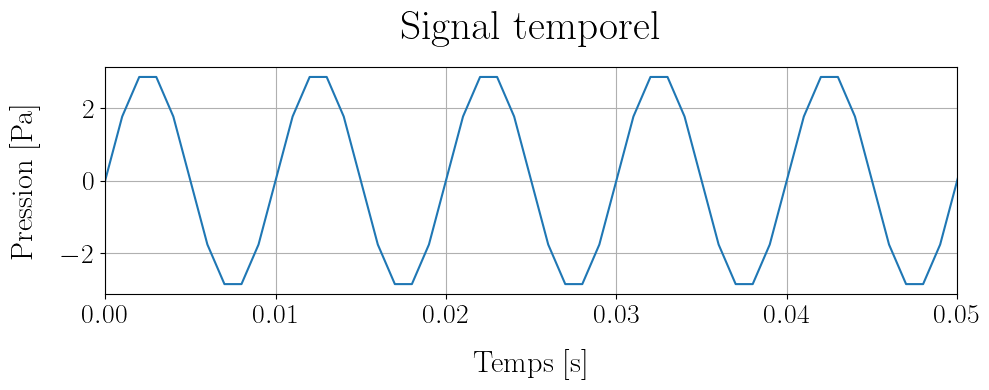

In [2]:
# Paramètres
fs = 1000  # fréquence d'échantillonnage (Hz)
T = 2  # durée (s)


# Signal
A = 3  # amplitude (Pa)
f0 = 100  # fréquence du signal (Hz)
t = np.arange(0, T, 1 / fs)
x = A * np.sin(2 * np.pi * f0 * t)  # unité : Pa
N = len(x)

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlim(0, 0.05)
plt.xlabel("Temps [s]")
plt.ylabel("Pression [Pa]")
plt.title("Signal temporel")
plt.grid(True)
plt.show()

# Valeur efficace 

La valeur RMS (Root Mean Square) est définie par

$$
p_{\text{rms}} = \sqrt{\frac{1}{N} \sum_{n=0}^{N-1} x^2[n]}
$$

et est exprimée en Pa. 

[1] parle de "root-power quantities"

In [3]:
p_rms = np.sqrt(np.mean(x**2))

print(f"RMS = {p_rms:.6f} Pa")

RMS = 2.121320 Pa


Ici, le signal est harmonique et on a donc :

$$
p_{\text{rms}} = \frac{A}{\sqrt{2}} 
$$

In [4]:
print(f"A / sqrt(2) = {A/np.sqrt(2):.6f} Pa")

A / sqrt(2) = 2.121320 Pa


# Sound Pressure Level (SPL) 

[1] :
Metrics computed from the sound pressure are often expressed as a level in decibels, such as SPL. In general, a level of a quantity Q is the logarithm of a ratio of Q to a specified reference value, Q0, of that quantity :

$$
L_Q \equiv \log_{\beta} \frac{Q}{Q_0} [L_Q]
$$

Complete specification of the level requires the unit $[L_Q]$ and reference value $Q_0$ to be specified. The base β is also needed, and usually follows once the unit is stated. When a **power quantity** $Q_P$ is expressed as a level in decibels, this equation becomes

$$
L_P \equiv 10 \log_{10} \frac{Q_P}{Q_{P,0}} \,  \text{dB}
$$

For **root-power** quantities : 

$$
L_P \equiv 20 \log_{10} \frac{Q_P^{1/2}}{Q_{P,0}^{1/2}} \,  \text{dB}
$$

## Définition 

**mean-square sound pressure level** :

$$
L_p \equiv 10 \log_{10} \frac{\overline{p^2}}{p_0^2} \,  \text{dB}
$$

où $\overline{p^2}$ est la pression quadratique moyenne (mean-square sound pressure). Cette définition est équivalente au **root-mean-
square sound pressure level** :

$$
L_p \equiv 20 \log_{10} \frac{(\overline{p^2})^{1/2}}{(p_0^2)^{1/2}}  = 20 \log_{10} \frac{p_{\text{rms}}}{p_0}\,  \text{dB}
$$

Ce niveau est souvent abbrégé en **Sound Pressure Level** ou SPL et est noté $L_p$ ou $L_{p, \text{rms}}$.

**Remarque importante** : No frequency or time weighting is involved in $L_p$ (SPL or Lrms)

**Valeur de référence** : La question est de savoir quelle valeur de référence doit on renseigner. Ici on peut donner, au choix, 

* les niveaux en dB re $p_0^2$ ($1 \mu \text{Pa}^2$) dans le cas où l'on considère la première définition avec la règle des $10 \log_{10}$.
* les niveaux en dB re $p_0$ ($1 \mu \text{Pa}$) dans le cas où l'on considère la seconde définition avec la règle des $20 \log_{10}$.

Il est également nécessaire de préciser la bande de fréquence considérée ainsi que le temps de moyennage considéré. 




In [5]:
p0 = 1e-6

# First definition of SPL
Lp = 10 * np.log10(p_rms**2 / p0**2)
print(f"SPL = {Lp:.2f} dB re 1 µPa^2")

# Second definition of SPL
Lp = 20 * np.log10(p_rms / p0)
print(f"SPL = {Lp:.2f} dB re 1 µPa")

SPL = 126.53 dB re 1 µPa^2
SPL = 126.53 dB re 1 µPa


# Domaine fréquentiel 

## Transformée de Fourier discrète (DFT) 
La transformée de Fourier discrète est classiquement définie par

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi k \frac{n}{N} }
$$

Comme cette opération consiste uniquement à sommer des valeurs exprimées en Pascal, la FFT brute possède également l'unité Pa.

La transformée de Fourier discrète inverse est donnée par : 

$$
x[n] = \sum_{k=0}^{K-1} X[k] e^{+j2\pi k \frac{n}{N} }
$$

Cependant, chaque coefficient est proportionnel au nombre d'échantillons $N$. La FFT brute ne représente donc pas directement une amplitude physique. 

**Remarque** : La DFT ne possède pas les mêmes unités que la transformée de Fourier continue. En effet, les valeurs de la transformée de Fourier ont pour unité Pa s ou de manière équivalente Pa / Hz. 

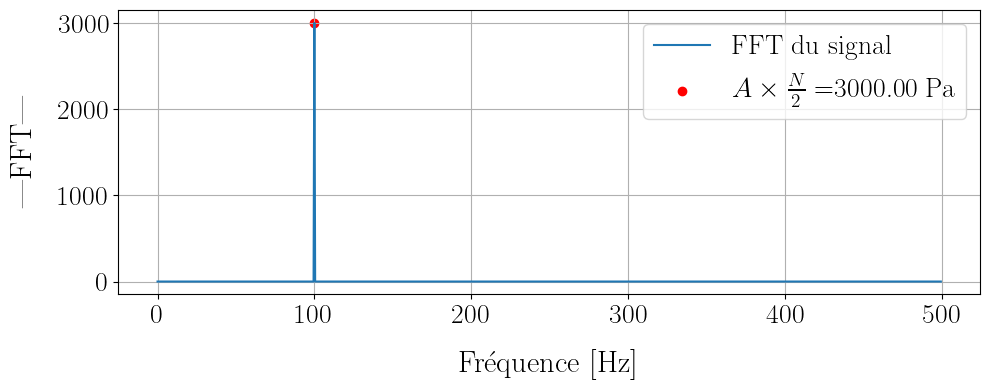

In [6]:
X = np.fft.fft(x)

f = np.fft.fftfreq(len(x), 1 / fs)

plt.figure(figsize=(10, 4))
plt.plot(f[: len(f) // 2], np.abs(X[: len(f) // 2]), label="FFT du signal")
plt.scatter(
    f0,
    A * len(x) / 2,
    color="red",
    label=r"$A \times \frac{N}{2} = $" + f"{A * len(x) / 2:.2f} Pa",
)
plt.xlabel("Fréquence [Hz]")
plt.ylabel("|FFT|")
plt.grid(True)
plt.legend()
# plt.show()

In [7]:
print(f"Fréquence de la composante principale : {f[np.argmax(np.abs(X))]:.2f} Hz")
print(f"Amplitude de la composante principale : {np.max(np.abs(X)):.2f} Pa")
print(f"A * N/2 = {A * N / 2:.2f} Pa")

Fréquence de la composante principale : 100.00 Hz
Amplitude de la composante principale : 3000.00 Pa
A * N/2 = 3000.00 Pa


On observe que le pic est de $\frac{N}{2}$ ce qui montre que la FFT brute dépend directement du nombre d'échantillons.

### Normalisation de la DFT 
Différentes conventions de normalisation peuvent être utilisées. 

#### Backward 
Dans numpy la normalisation appliquée par défaut est la normalisation **backward** donnée par : 

Transformée : 

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi k \frac{n}{N} }
$$

Transformée inverse :
$$
x[n] = \frac{1}{N} \sum_{k=0}^{K-1} X[k] e^{+j2\pi k \frac{n}{N} }
$$

Dans ce cas l'amplitude du spectre du signal est de $A \frac{N}{2}$.

#### Forward 
On peut également appliquée la normalisation **forward** donnée par : 

Transformée : 

$$
X[k] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] e^{-j2\pi k \frac{n}{N} }
$$

Transformée inverse :
$$
x[n] =  \sum_{k=0}^{K-1} X[k] e^{+j2\pi k \frac{n}{N} }
$$

Dans ce cas l'amplitude du spectre du signal est de $A \frac{1}{2}$.

#### Ortho

$$
X[k] = \frac{1}{\sqrt{N}} \sum_{n=0}^{N-1} x[n] e^{-j2\pi k \frac{n}{N} }
$$

Transformée inverse :
$$
x[n] =  \frac{1}{\sqrt{N}}  \sum_{k=0}^{K-1} X[k] e^{+j2\pi k \frac{n}{N} }
$$

Dans ce cas l'amplitude du spectre du signal est de $A \frac{\sqrt{N}}{2}$.


In [8]:
# On peut vérifier numériquement
print(f"A N/2 = {A * N/2:.1f}")
print(f"A 1/2 = {A * 1/2:.1f}")
print(f"A sqrt(N)/2 = {A * np.sqrt(N)/2:.1f}")

for norm in ["backward", "forward", "ortho"]:

    X = np.fft.fft(x, norm=norm)

    print(f"DFT using {norm} normalisation :")
    print(f"\t Maximal spectral amplitude = {np.max(np.abs(X)):.1f}")



A N/2 = 3000.0
A 1/2 = 1.5
A sqrt(N)/2 = 67.1
DFT using backward normalisation :
	 Maximal spectral amplitude = 3000.0
DFT using forward normalisation :
	 Maximal spectral amplitude = 1.5
DFT using ortho normalisation :
	 Maximal spectral amplitude = 67.1


## Densité spectrale de puissance (PSD)

### Calcul par DFT 



In [9]:
X = np.fft.rfft(x, norm="forward")
fX = np.fft.rfftfreq(N, d=1 / fs)
df = fs / N

# Calcul de la densité spectrale de puissance 
Sxx_fft = np.abs(X) ** 2 / df

# Passage en spectre unilatéral
Sxx_fft[1:-1] *= 2

### Calcul avec la méthode de Welch (scipy)

Afin de comparer au calcul direct on utilise les paramètres suivant : 
* *window* = "boxcar"
* *nperseg* = N 

Ainsi, le calcul s'effectue sur une unique fenêtre et il n'y pas de pondération (fenêtre rectangulaire). 

In [10]:
from scipy import signal

f, Sxx = signal.welch(x, fs=fs, window="boxcar", nperseg=N, scaling="density")

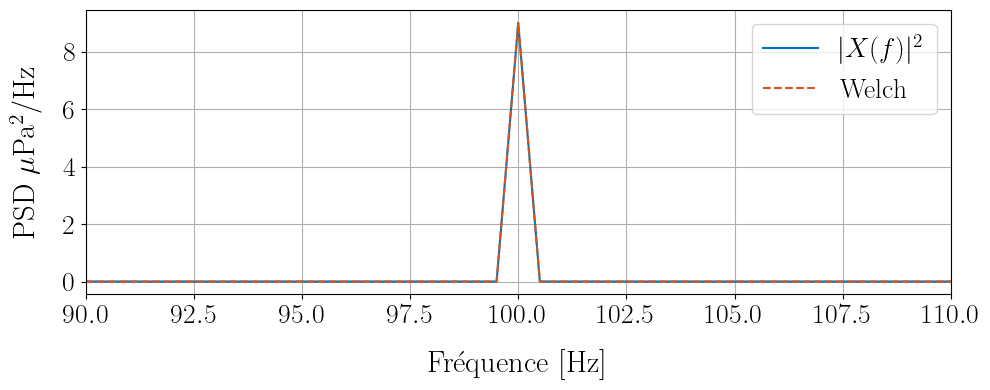

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(fX, Sxx_fft, label=r"$\lvert X(f) \rvert^2$", color=color(0))
plt.plot(f, Sxx, label="Welch", color=color(1), linestyle="--")

plt.xlabel("Fréquence [Hz]")
plt.ylabel(r"PSD $\mu$Pa$^2$/Hz")
plt.xlim(f0*0.9, f0*1.1)
plt.legend()
plt.grid()
plt.show()

In [12]:
print(f"Equals : {np.allclose(Sxx, Sxx_fft)}")

Equals : True


Les deux calculs conduisent a priori à des résultats similaires. 

### Lien avec la puissance RMS 

Par définition de la densité spectrale de puissance on a : 

$$
p_{\text{rms}}^2 = \int S_{xx}(f) df
$$

In [13]:
# RMS dans le domaine temporel
power_time = np.mean(x**2)

# Puissance obtenue en intégrant la PSD Welch
df = f[1] - f[0]
power_welch = np.sum(Sxx) * df

# Puissance obtenue avec notre PSD FFT
power_fft = np.sum(Sxx_fft) * df

print(f"Temporel : {power_time:.2f} Pa²")
print(f"Welch    : {power_welch:.2f} Pa²")
print(f"FFT      : {power_fft:.2f} Pa²")

Temporel : 4.50 Pa²
Welch    : 4.50 Pa²
FFT      : 4.50 Pa²


### Niveau de DSP (Spectral Density Levels)

Par convention, puisque l'on manipule des puissances, on considère la convention en 10 log10 et les niveaux de densité spectrale de puissance sont référencés à $1\mu \text{Pa}^2 / \text{Hz}$. 

**Autre convention** : dans le cas où l'on considère la convention 20 log les niveaux de DSP sont référencés à $1\mu \text{Pa} / \sqrt{\text{Hz}}$

$$
L_{\text{PSD}} = 10 \log_{10} \left ( \frac{S_{xx}(f)}{p_0^2 / f_0} \right )
$$

avec $p_0 = 1~\mu \text{Pa}$ et $f_0 = 1~\text{Hz}$

In [14]:
L_psd_fft = 10 * np.log10(Sxx_fft / p0**2)
L_psd = 10 * np.log10(Sxx / p0**2)


In [15]:
print(f"Equals : {np.allclose(L_psd_fft, L_psd, atol=0.01, rtol=0.01)}")
err = L_psd - L_psd_fft
print(f"Max diff : {np.max(np.abs(err)):.2f}")
print(f"Max diff index : {np.argmax(np.max(np.abs(err)))}")

Equals : False
Max diff : 9.99
Max diff index : 0


L'erreur maximale est de 10 dB ce qui est loin d'être négligeable. Elle correspond à la fréquence f=0 et est due au mode de calcul par défaut de scipy. 

En effet, la méthode de welch utilise le paramètre **detrend**='constant' par défaut et la DSP est calculé pour le signal centré 
$$
\tilde{x}[n] = x[n] - \bar{x}
$$

In [16]:
print("mean(x) =", np.mean(x))
print("X[0]    =", X[0])
print("abs(X[0])² =", np.abs(X[0]) ** 2)
print("Sxx[0]  =", Sxx[0])
print("Sxx_fft[0] =", Sxx_fft[0])

mean(x) = 3.552713678800501e-16
X[0]    = (3.7511435991005684e-16+0j)
abs(X[0])² = 1.4071078301073167e-31
Sxx[0]  = 2.818547744704277e-32
Sxx_fft[0] = 2.8142156602146333e-31


Pour sans convaincre on peut mettre ce paramètre à False.

In [17]:
f, Sxx = signal.welch(
    x, fs=fs, window="boxcar", nperseg=N, scaling="density", detrend=False
)
L_psd = 10 * np.log10(Sxx / p0**2)
L_psd

array([-185.50642625, -171.45858238, -188.56228853, ..., -176.94970351,
       -177.92421054, -183.4680044 ])

In [18]:
print(f"Equals : {np.allclose(L_psd_fft, L_psd, atol=0.01, rtol=0.01)}")
err = L_psd - L_psd_fft
print(f"Max diff : {np.max(np.abs(err)):.2f}")
print(f"Max diff index : {np.argmax(np.max(np.abs(err)))}")

Equals : True
Max diff : 0.59
Max diff index : 0


Après correction les deux calculs coïncident (aux erreurs numériques près).

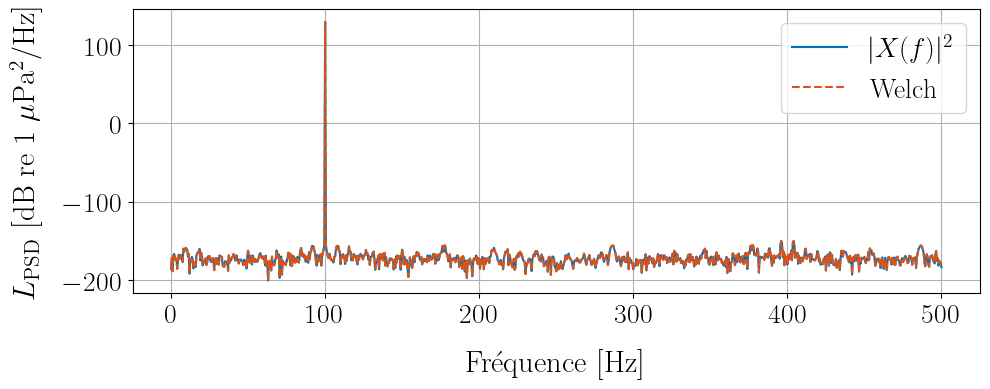

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(fX, L_psd_fft, label=r"$\lvert X(f) \rvert^2$", color=color(0), linestyle="-")
plt.plot(f, L_psd, label="Welch", color=color(1), linestyle="--")
plt.xlabel("Fréquence [Hz]")
plt.ylabel(r"$L_{\text{PSD}}$ [dB re 1 $\mu$Pa$^2$/Hz]")
plt.legend()
plt.grid()
plt.show()

# Spectral Density Levels 

Spectral Density Levels: Either sound exposure (E) or
mean-square sound pressure (p2) can be expressed as a spectral
density level. For example, if ΔE and Δp2 are the sound exposure
and mean-square sound pressure in a specified frequency
band (bandwidth Δf), the energy spectral density level (with
reference to p 2
0 t0/f0) and power spectral density level (with
reference to p 2
0 /f0) are, respectively
LE,f = 10log10
ΔE/Δf
p 2
0 t0/f0
dB (16)
and
Lp,f = 10log10
Δp2/Δf
p 2
0 /f0
dB (17)
where the reference value f0 is 1 Hz.